# 02 — Engenharia de Features do Rio Doce

Este notebook documenta a **Fase 2 do Estudo de Caso 2** do framework de MLOps, com foco na **engenharia de features** para a predição do nível do Rio Doce.

## Objetivos deste notebook

- carregar a base oficial de features gerada pela etapa canônica em `src/river_level/features.py`;
- validar a estrutura da base resultante;
- inspecionar as famílias de features criadas;
- gerar visualizações para apoiar a interpretação hidrológica;
- registrar evidências úteis para a dissertação e para a continuidade da Fase 3.

## Posição deste notebook no framework

A sequência lógica do Caso 2, até este ponto, é:

1. **Fase 1 — ingestão e pré-processamento** Consolidação da base oficial de modelagem.

2. **Fase 2 — engenharia de features** Geração de variáveis derivadas com base na dinâmica hidrológica e temporal.

3. **Fase 3 — sequências e modelagem** Estruturação para LSTM e demais modelos supervisionados.

> Este notebook não substitui a execução oficial via YAML/CLI.  
> Seu papel é **inspecionar, validar e documentar** a base de features já gerada.

## 1. Importações e configuração inicial

Nesta etapa são carregadas as bibliotecas utilizadas para inspeção da base e geração dos gráficos.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 2. Caminhos dos arquivos

São definidos os caminhos da base processada da Fase 1, da base oficial de features da Fase 2 e do resumo JSON gerado pela execução.

In [2]:
from pathlib import Path

# 1. Função robusta para encontrar a raiz do projeto (FrameWork_MLOps_Unificado)
def encontrar_raiz(caminho_atual=Path.cwd().resolve()):
    for pai in [caminho_atual] + list(caminho_atual.parents):
        if (pai / "src").exists() or (pai / "data").exists():
            return pai
    return caminho_atual.parents[1] # fallback

RAIZ_PROJETO = encontrar_raiz()
print("Raiz do projeto detectada:", RAIZ_PROJETO)

# 2. Montar os caminhos unindo a raiz com as pastas
CAMINHO_BASE_PROCESSADA = RAIZ_PROJETO / "data/processed/river_level/dataset_base_modelagem.csv"
CAMINHO_BASE_FEATURES = RAIZ_PROJETO / "data/processed/river_level/dataset_features_baseline_lstm.csv"
CAMINHO_RESUMO = RAIZ_PROJETO / "artifacts/river_level/engenharia_features/resumo_features_baseline_lstm.json"

# 3. Testar
print("\nBase processada existe? ", CAMINHO_BASE_PROCESSADA.exists())
print("Base de features existe?", CAMINHO_BASE_FEATURES.exists())
print("Resumo existe?         ", CAMINHO_RESUMO.exists())

Raiz do projeto detectada: C:\Users\guerr\OneDrive\Documents\VSCode\FrameWork_MLOps_Unificado

Base processada existe?  True
Base de features existe? True
Resumo existe?          True


## 3. Carregamento das bases

A base processada representa a saída da Fase 1.  
A base de features representa a saída oficial da Fase 2.

In [3]:
df_base = pd.read_csv(
    CAMINHO_BASE_PROCESSADA,
    parse_dates=["Data"],
    index_col="Data",
    encoding="utf-8-sig",
)

df_features = pd.read_csv(
    CAMINHO_BASE_FEATURES,
    parse_dates=["Data"],
    index_col="Data",
    encoding="utf-8-sig",
)

print("Shape df_base:     ", df_base.shape)
print("Shape df_features: ", df_features.shape)

Shape df_base:      (7749, 2)
Shape df_features:  (7659, 36)


## 4. Inspeção estrutural inicial

Esta etapa confirma:

- formato das bases;
- intervalo temporal;
- presença de valores ausentes;
- colunas disponíveis após a engenharia de features.

In [4]:
print("Período df_base:")
print(df_base.index.min(), "->", df_base.index.max())

print("\nPeríodo df_features:")
print(df_features.index.min(), "->", df_features.index.max())

print("\nQuantidade total de NaN em df_features:")
print(int(df_features.isna().sum().sum()))

print("\nPrimeiras linhas da base de features:")
display(df_features.head())

print("\nÚltimas linhas da base de features:")
display(df_features.tail())

Período df_base:
2005-01-01 00:00:00 -> 2026-03-20 00:00:00

Período df_features:
2005-04-01 00:00:00 -> 2026-03-20 00:00:00

Quantidade total de NaN em df_features:
0

Primeiras linhas da base de features:


,Nivel,Precip_Media_Estacoes,Precip_Log,API,Dias_Estiagem_<5mm,Dias_Estiagem_<10mm,Dias_Estiagem_<15mm,Nivel_Media_3d,Nivel_Tendencia_3d,Nivel_Media_7d,Nivel_Tendencia_7d,Nivel_Media_15d,Nivel_Tendencia_15d,Nivel_Lag_1d,Nivel_Lag_3d,Nivel_Lag_7d,Nivel_Lag_15d,Nivel_Lag_30d,Nivel_Lag_60d,Nivel_Lag_90d,Precip_Log_Lag_1d,Precip_Log_Lag_3d,Precip_Log_Lag_7d,Precip_Log_Lag_15d,Precip_Log_Lag_30d,Precip_Log_Lag_60d,Precip_Log_Lag_90d,API_Lag_1d,API_Lag_3d,API_Lag_7d,API_Lag_15d,API_Lag_30d,API_Lag_60d,API_Lag_90d,Seno_DiaAno,Cosseno_DiaAno
Data,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2005-04-01,4.05,8.6985,2.271971,42.462911,0,11,11,4.130000,-0.17,4.172857,-0.13,4.390000,-0.15,4.13,4.22,4.18,4.20,4.83,4.05,4.16,0.061565,0.410784,0.000000,0.000000,2.706015,0.410784,0.174373,46.086316,53.672561,61.884708,75.212923,120.547094,109.303836,0.190500,0.999986,0.005376
2005-04-02,4.05,0.6350,0.491643,47.764378,1,12,12,4.076667,-0.16,4.152857,-0.14,4.380000,-0.15,4.05,4.21,4.19,4.20,5.15,4.11,3.99,2.271971,0.174373,1.659180,0.000000,3.401947,2.003438,2.589041,42.462911,49.886756,56.933932,69.195889,124.872827,101.067530,0.365760,0.999930,-0.011826
2005-04-03,4.03,56.3925,4.049914,44.578228,0,0,0,4.043333,-0.10,4.127143,-0.18,4.368000,-0.18,4.05,4.13,4.21,4.21,5.71,4.00,4.06,0.491643,0.061565,0.410784,2.020222,0.061565,3.474943,3.032426,47.764378,46.086316,56.634217,63.660218,143.905501,99.396627,12.653499,0.999579,-0.029025
2005-04-04,4.01,0.0000,0.000000,97.404469,1,1,1,4.030000,-0.04,4.100000,-0.19,4.344000,-0.36,4.03,4.05,4.20,4.37,7.56,3.97,3.76,4.049914,2.271971,1.835776,1.316408,0.061565,2.985429,0.874218,44.578228,42.462911,52.611480,65.107401,132.456561,122.740897,31.388719,0.998932,-0.046215
2005-04-05,3.89,0.0000,0.000000,89.612112,2,2,2,3.976667,-0.16,4.052857,-0.33,4.234667,-1.64,4.01,4.05,4.22,5.53,8.27,3.70,3.61,0.000000,0.491643,0.410784,3.123092,0.174373,1.208512,2.499508,97.404469,47.764378,53.672561,62.628809,121.923536,131.716625,30.274622,0.997989,-0.063391



Últimas linhas da base de features:


,Nivel,Precip_Media_Estacoes,Precip_Log,API,Dias_Estiagem_<5mm,Dias_Estiagem_<10mm,Dias_Estiagem_<15mm,Nivel_Media_3d,Nivel_Tendencia_3d,Nivel_Media_7d,Nivel_Tendencia_7d,Nivel_Media_15d,Nivel_Tendencia_15d,Nivel_Lag_1d,Nivel_Lag_3d,Nivel_Lag_7d,Nivel_Lag_15d,Nivel_Lag_30d,Nivel_Lag_60d,Nivel_Lag_90d,Precip_Log_Lag_1d,Precip_Log_Lag_3d,Precip_Log_Lag_7d,Precip_Log_Lag_15d,Precip_Log_Lag_30d,Precip_Log_Lag_60d,Precip_Log_Lag_90d,API_Lag_1d,API_Lag_3d,API_Lag_7d,API_Lag_15d,API_Lag_30d,API_Lag_60d,API_Lag_90d,Seno_DiaAno,Cosseno_DiaAno
Data,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2026-03-16,4.340227,0.1905,0.174373,78.069528,2,14,17,3.831702,0.867913,3.385950,1.547525,3.354432,0.372204,3.631041,3.472315,2.792702,3.968024,3.377000,2.033843,2.122842,0.669111,2.383566,1.932405,2.747623,0.000000,0.000000,2.278446,83.822857,77.008314,70.454715,80.746622,39.288005,46.210309,63.062808,0.960885,0.276946
2026-03-17,4.133842,1.7775,1.021551,72.014466,3,15,18,4.035037,0.610005,3.569534,1.285086,3.349514,-0.073763,4.340227,3.523837,2.848756,4.207605,3.105149,2.023770,2.484067,0.174373,2.359627,2.065653,2.603319,0.000000,0.000000,3.273364,78.069528,80.691149,70.724437,88.892393,36.144965,42.513484,66.779284,0.965507,0.260376
2026-03-18,3.739820,1.2700,0.819780,68.030809,4,16,19,4.071297,0.108779,3.689703,0.841183,3.320911,-0.429043,4.133842,3.631041,2.898637,4.168863,2.905948,2.009560,3.259886,1.021551,0.669111,2.183216,0.000000,1.694698,0.000000,2.589192,72.014466,83.822857,71.956932,94.289501,33.253368,39.112406,86.836941,0.969843,0.243730
2026-03-19,3.194679,4.6340,1.728820,63.858344,5,17,20,3.689447,-1.145548,3.719395,0.207843,3.293957,-0.404308,3.739820,4.340227,2.986836,3.598987,2.682046,2.047214,3.265487,0.819780,0.174373,2.288400,0.685291,0.000000,0.174373,0.950692,68.030809,78.069528,74.075178,86.746341,35.038098,35.983413,92.208986,0.973892,0.227011
2026-03-20,2.971323,23.8775,3.213964,63.383676,0,0,0,3.301941,-1.162519,3.647824,-0.500992,3.280548,-0.201142,3.194679,4.133842,3.472315,3.172465,2.626204,2.057483,3.534733,1.728820,1.021551,2.383566,1.088124,1.189671,2.763737,0.601854,63.858344,72.014466,77.008314,80.790984,32.235050,33.295240,86.419767,0.977653,0.210225


## 5. Conferência das colunas geradas

A base de features deve preservar as colunas originais e acrescentar as famílias de variáveis derivadas definidas para o estudo.

In [5]:
colunas = df_features.columns.tolist()

print(f"Total de colunas: {len(colunas)}")
print("\nColunas da base de features:")
for coluna in colunas:
    print("-", coluna)

Total de colunas: 36

Colunas da base de features:
- Nivel
- Precip_Media_Estacoes
- Precip_Log
- API
- Dias_Estiagem_<5mm
- Dias_Estiagem_<10mm
- Dias_Estiagem_<15mm
- Nivel_Media_3d
- Nivel_Tendencia_3d
- Nivel_Media_7d
- Nivel_Tendencia_7d
- Nivel_Media_15d
- Nivel_Tendencia_15d
- Nivel_Lag_1d
- Nivel_Lag_3d
- Nivel_Lag_7d
- Nivel_Lag_15d
- Nivel_Lag_30d
- Nivel_Lag_60d
- Nivel_Lag_90d
- Precip_Log_Lag_1d
- Precip_Log_Lag_3d
- Precip_Log_Lag_7d
- Precip_Log_Lag_15d
- Precip_Log_Lag_30d
- Precip_Log_Lag_60d
- Precip_Log_Lag_90d
- API_Lag_1d
- API_Lag_3d
- API_Lag_7d
- API_Lag_15d
- API_Lag_30d
- API_Lag_60d
- API_Lag_90d
- Seno_DiaAno
- Cosseno_DiaAno


## 6. Separação das famílias de features

Para facilitar a análise, as colunas são agrupadas por famílias semânticas.

In [6]:
colunas_originais = [
    col for col in df_features.columns
    if col in ["Nivel", "Precip_Media_Estacoes"]
]

colunas_transformacao_precip = [
    col for col in df_features.columns
    if col in ["Precip_Log", "API"]
]

colunas_estiagem = [
    col for col in df_features.columns
    if "Dias_Estiagem_" in col
]

colunas_medias_nivel = [
    col for col in df_features.columns
    if "Nivel_Media_" in col
]

colunas_tendencia_nivel = [
    col for col in df_features.columns
    if "Nivel_Tendencia_" in col
]

colunas_lags = [
    col for col in df_features.columns
    if "_Lag_" in col
]

colunas_sazonalidade = [
    col for col in df_features.columns
    if col in ["Seno_DiaAno", "Cosseno_DiaAno"]
]

print("Colunas originais:", colunas_originais)
print("Transformação de precipitação/API:", colunas_transformacao_precip)
print("Estiagem:", colunas_estiagem)
print("Médias móveis do nível:", colunas_medias_nivel)
print("Tendência do nível:", colunas_tendencia_nivel)
print("Sazonalidade:", colunas_sazonalidade)
print("Quantidade de lags:", len(colunas_lags))

Colunas originais: ['Nivel', 'Precip_Media_Estacoes']
Transformação de precipitação/API: ['Precip_Log', 'API']
Estiagem: ['Dias_Estiagem_<5mm', 'Dias_Estiagem_<10mm', 'Dias_Estiagem_<15mm']
Médias móveis do nível: ['Nivel_Media_3d', 'Nivel_Media_7d', 'Nivel_Media_15d']
Tendência do nível: ['Nivel_Tendencia_3d', 'Nivel_Tendencia_7d', 'Nivel_Tendencia_15d']
Sazonalidade: ['Seno_DiaAno', 'Cosseno_DiaAno']
Quantidade de lags: 21


## 7. Verificação da perda inicial de linhas

Como a maior defasagem utilizada foi de 90 dias, espera-se a remoção das linhas iniciais necessárias para preencher os lags e demais transformações.

In [7]:
linhas_base = len(df_base)
linhas_features = len(df_features)
linhas_perdidas = linhas_base - linhas_features

print("Linhas na base processada: ", linhas_base)
print("Linhas na base de features:", linhas_features)
print("Linhas perdidas:           ", linhas_perdidas)

print("\nPrimeira data df_base:    ", df_base.index.min())
print("Primeira data df_features:", df_features.index.min())

Linhas na base processada:  7749
Linhas na base de features: 7659
Linhas perdidas:            90

Primeira data df_base:     2005-01-01 00:00:00
Primeira data df_features: 2005-04-01 00:00:00


## 8. Análise visual das variáveis hidrológicas principais

Esta visualização ajuda a confirmar a coerência entre:

- nível do rio;
- precipitação média;
- precipitação transformada;
- API;
- média móvel de nível;
- tendência recente.

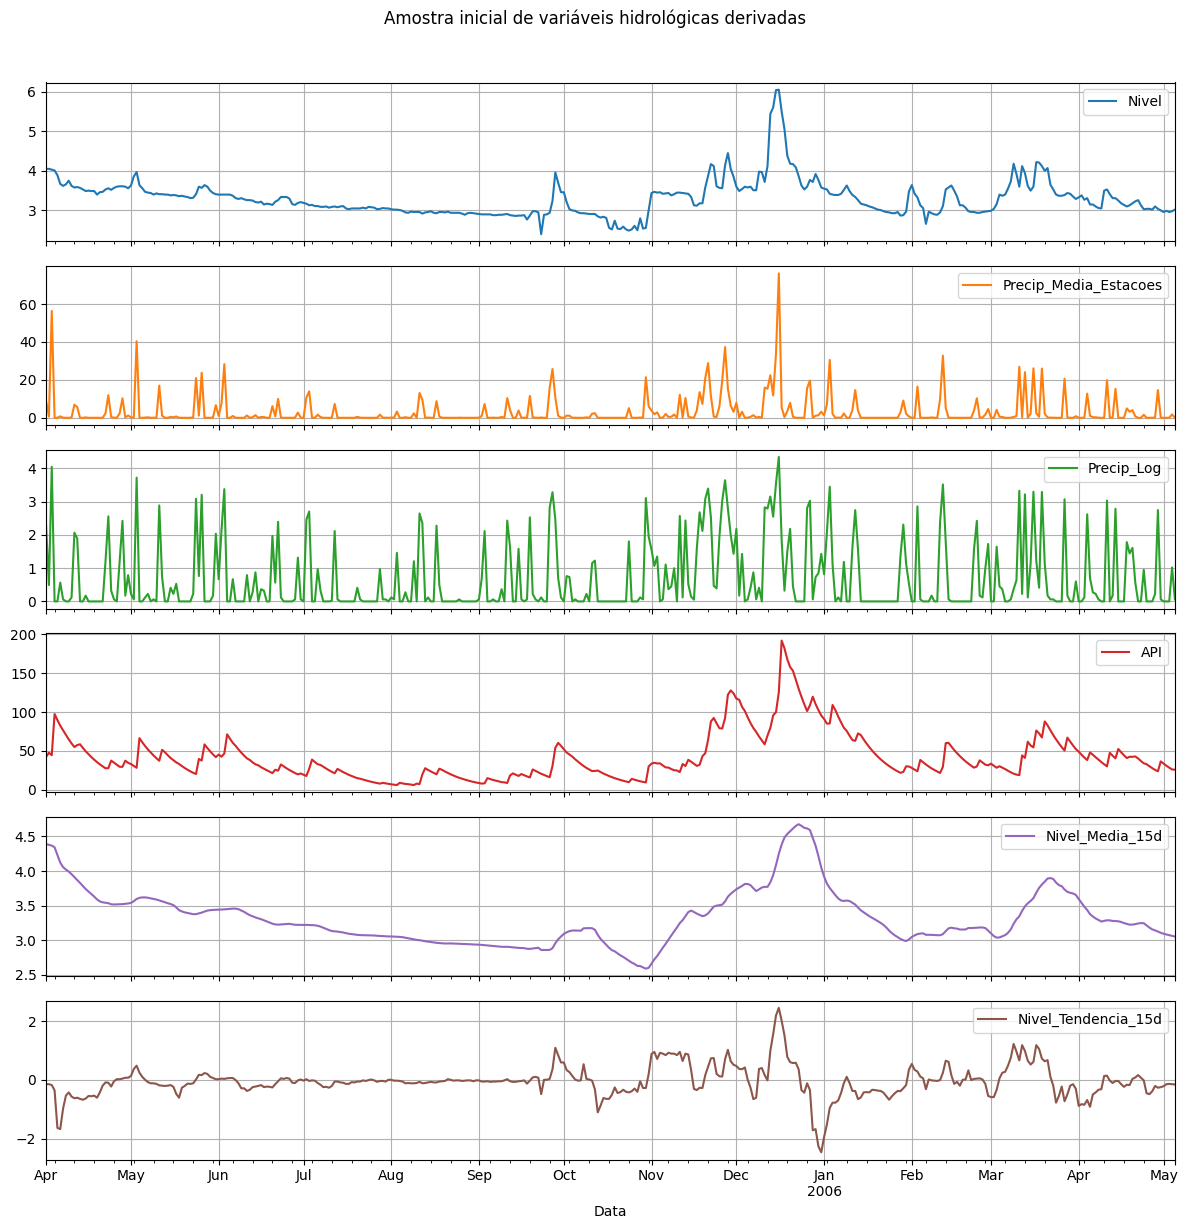

In [8]:
colunas_plot_principal = [
    "Nivel",
    "Precip_Media_Estacoes",
    "Precip_Log",
    "API",
    "Nivel_Media_15d",
    "Nivel_Tendencia_15d",
]

df_features[colunas_plot_principal].iloc[:400].plot(subplots=True, figsize=(12, 12), sharex=True)
plt.suptitle("Amostra inicial de variáveis hidrológicas derivadas", y=1.02)
plt.tight_layout()
plt.show()

## 9. Avaliação dos contadores de estiagem

Os contadores de estiagem ajudam a representar períodos secos sob diferentes limiares de precipitação.

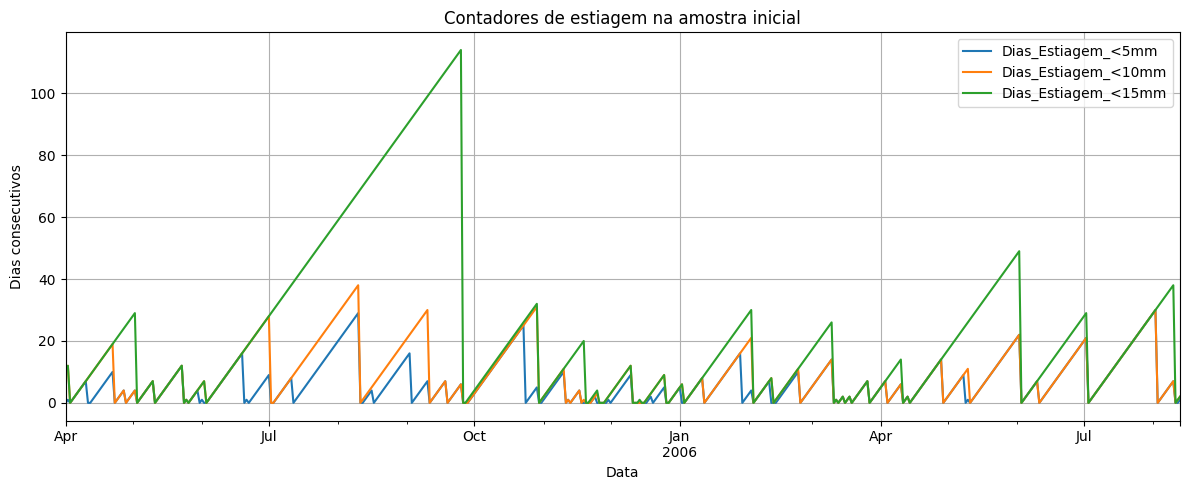

In [9]:
if colunas_estiagem:
    df_features[colunas_estiagem].iloc[:500].plot(figsize=(12, 5))
    plt.title("Contadores de estiagem na amostra inicial")
    plt.xlabel("Data")
    plt.ylabel("Dias consecutivos")
    plt.tight_layout()
    plt.show()

## 10. Avaliação das médias móveis e tendências do nível

Estas features representam o comportamento recente do nível do rio em diferentes janelas temporais.

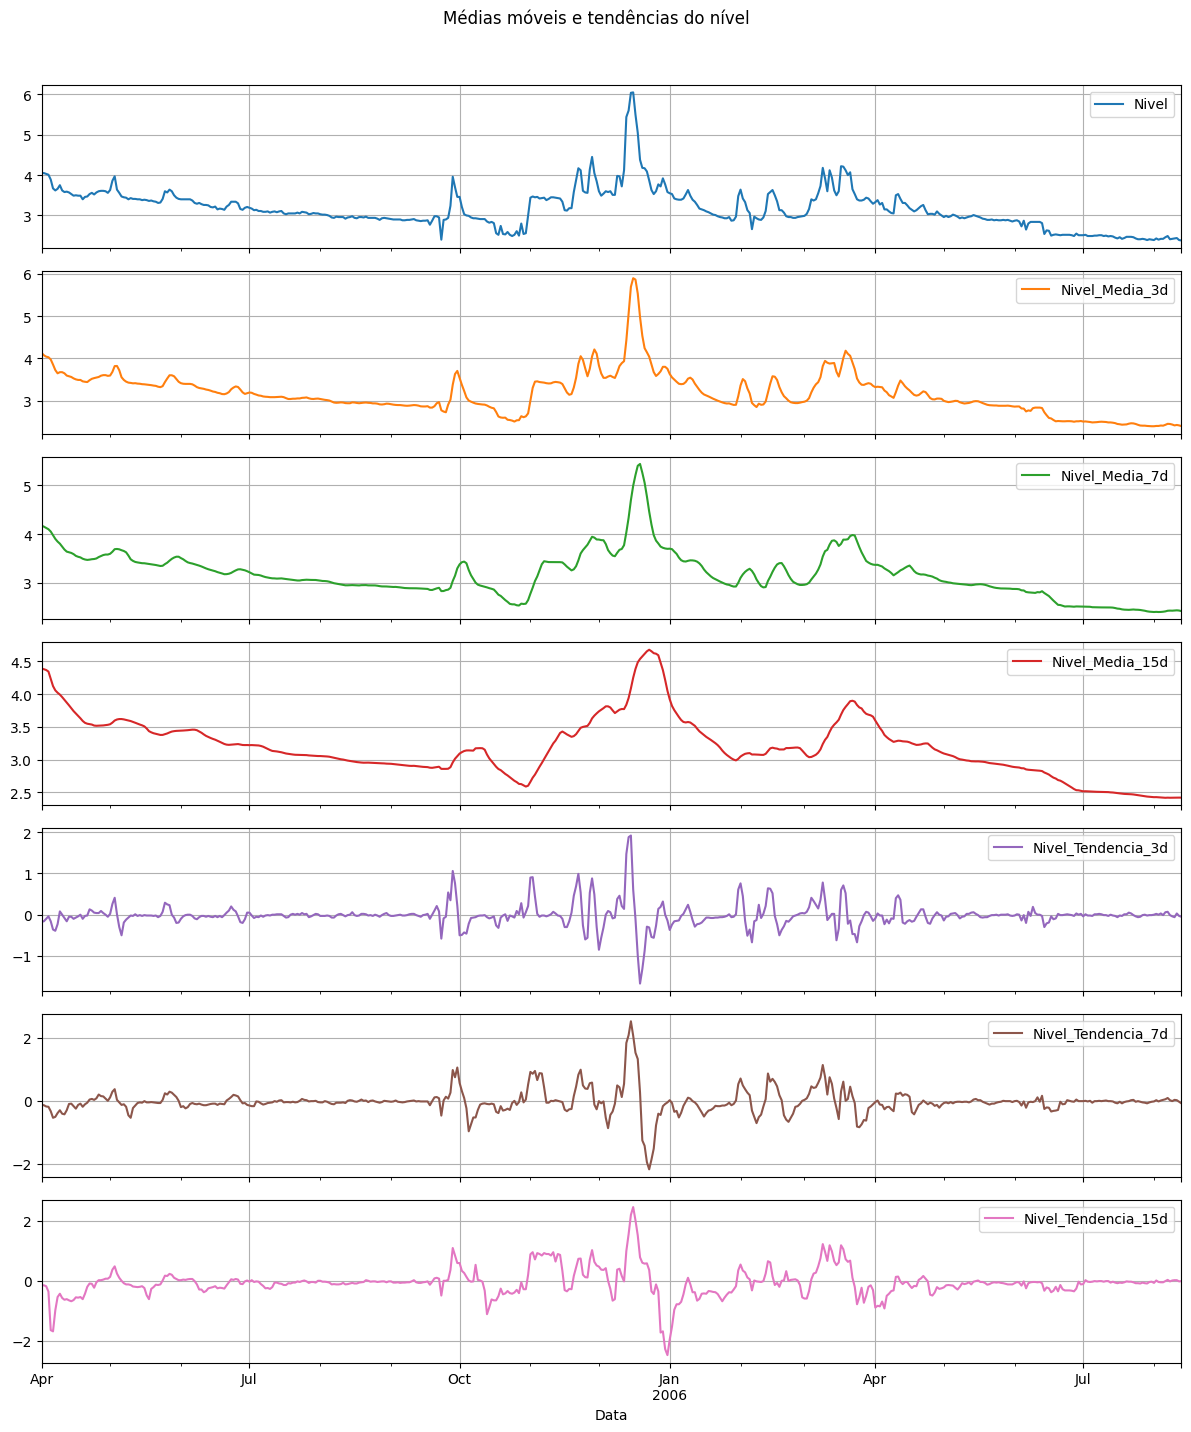

In [10]:
colunas_plot_nivel = ["Nivel"] + colunas_medias_nivel + colunas_tendencia_nivel
df_features[colunas_plot_nivel].iloc[:500].plot(subplots=True, figsize=(12, 14), sharex=True)
plt.suptitle("Médias móveis e tendências do nível", y=1.02)
plt.tight_layout()
plt.show()

## 11. Avaliação dos lags

Os lags representam memória explícita do sistema.  
Nesta inspeção, são mostradas algumas defasagens do nível, da precipitação logarítmica e do API.

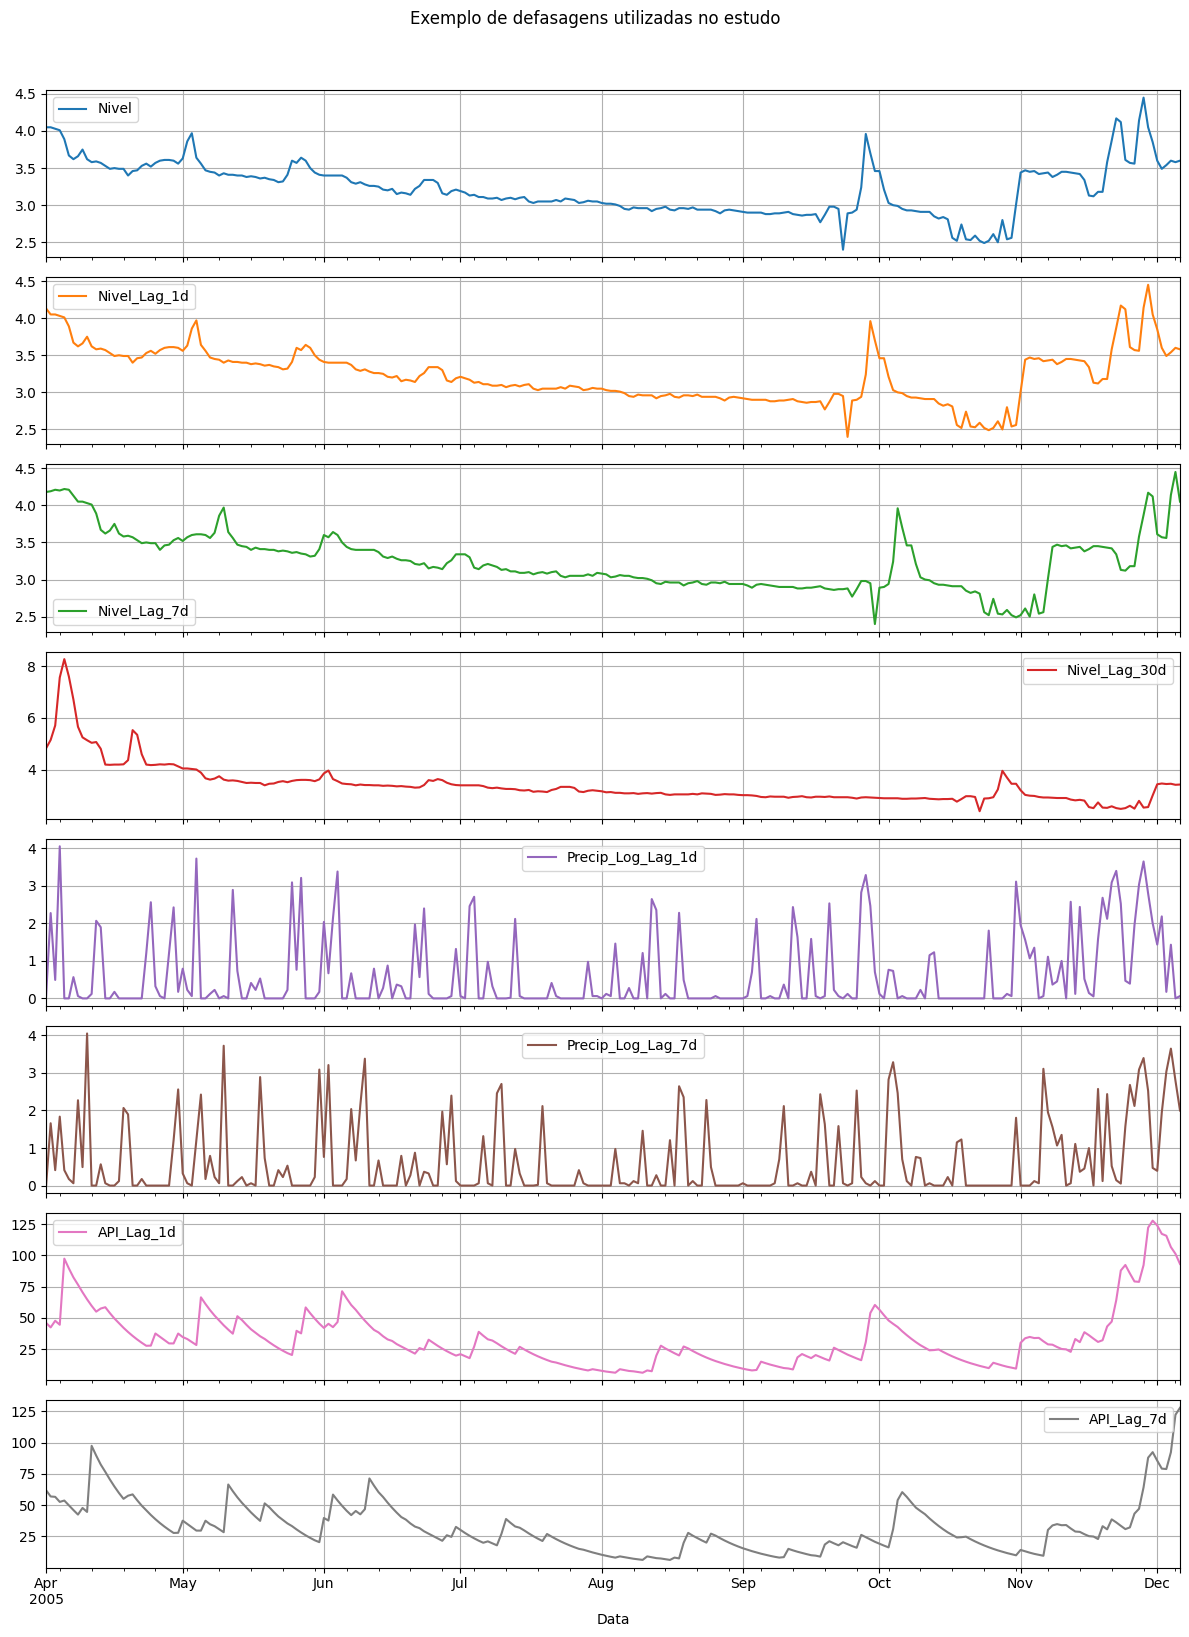

In [11]:
lags_exemplo = [
    "Nivel_Lag_1d",
    "Nivel_Lag_7d",
    "Nivel_Lag_30d",
    "Precip_Log_Lag_1d",
    "Precip_Log_Lag_7d",
    "API_Lag_1d",
    "API_Lag_7d",
]

colunas_lags_exemplo = [col for col in lags_exemplo if col in df_features.columns]

df_features[["Nivel"] + colunas_lags_exemplo].iloc[:250].plot(subplots=True, figsize=(12, 16), sharex=True)
plt.suptitle("Exemplo de defasagens utilizadas no estudo", y=1.02)
plt.tight_layout()
plt.show()

## 12. Sazonalidade anual

A codificação cíclica por seno e cosseno do dia do ano busca representar a sazonalidade sem quebrar a continuidade temporal.

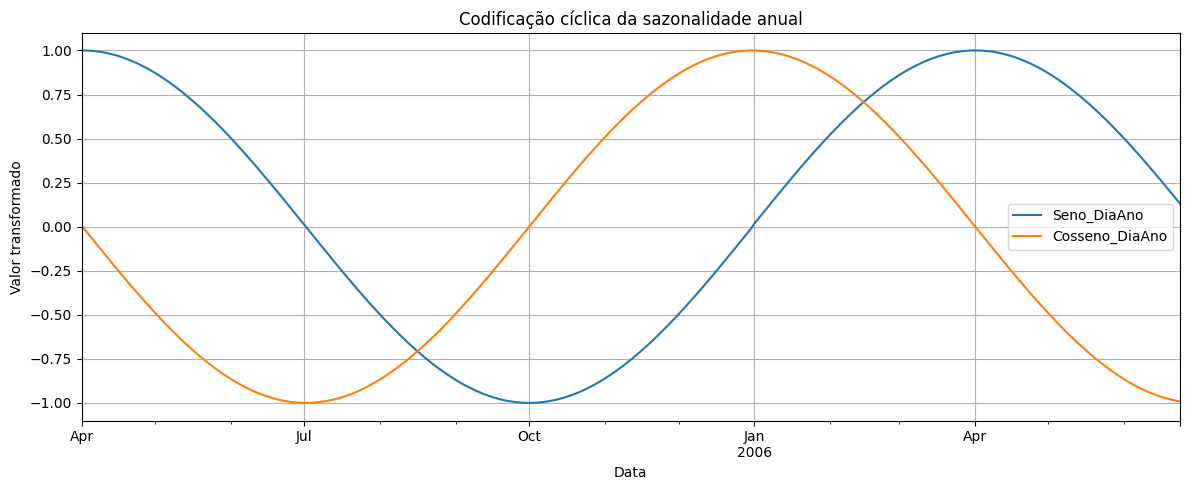

In [12]:
df_features[["Seno_DiaAno", "Cosseno_DiaAno"]].iloc[:450].plot(figsize=(12, 5))
plt.title("Codificação cíclica da sazonalidade anual")
plt.xlabel("Data")
plt.ylabel("Valor transformado")
plt.tight_layout()
plt.show()

## 13. Correlação das features com a variável alvo

Esta análise não define sozinha a qualidade das features, mas ajuda a inspecionar a força da relação linear com o nível do rio.

In [13]:
df_numerico = df_features.select_dtypes(include=np.number).copy()
correlacao = df_numerico.corr()

cor_target = (
    correlacao[["Nivel"]]
    .sort_values(by="Nivel", ascending=False)
)

display(cor_target.head(15))
display(cor_target.tail(15))

,Nivel
Nivel,1.000000
Nivel_Media_3d,0.981591
Nivel_Lag_1d,0.973703
Nivel_Media_7d,0.935196
Nivel_Lag_3d,0.889655
Nivel_Media_15d,0.887639
Nivel_Lag_7d,0.790424
Nivel_Lag_15d,0.724157
API,0.655013
API_Lag_1d,0.652308


,Nivel
Precip_Log_Lag_3d,0.296248
Nivel_Lag_90d,0.263653
Precip_Log_Lag_7d,0.258253
Precip_Log_Lag_1d,0.240286
Nivel_Tendencia_3d,0.234066
Precip_Log_Lag_15d,0.219952
Precip_Log,0.200079
Precip_Log_Lag_30d,0.191575
Precip_Media_Estacoes,0.180559
Precip_Log_Lag_60d,0.164822


## 14. Heatmap resumido das principais correlações

Para manter a visualização legível, são exibidas apenas as features com maior magnitude de correlação com a variável alvo.

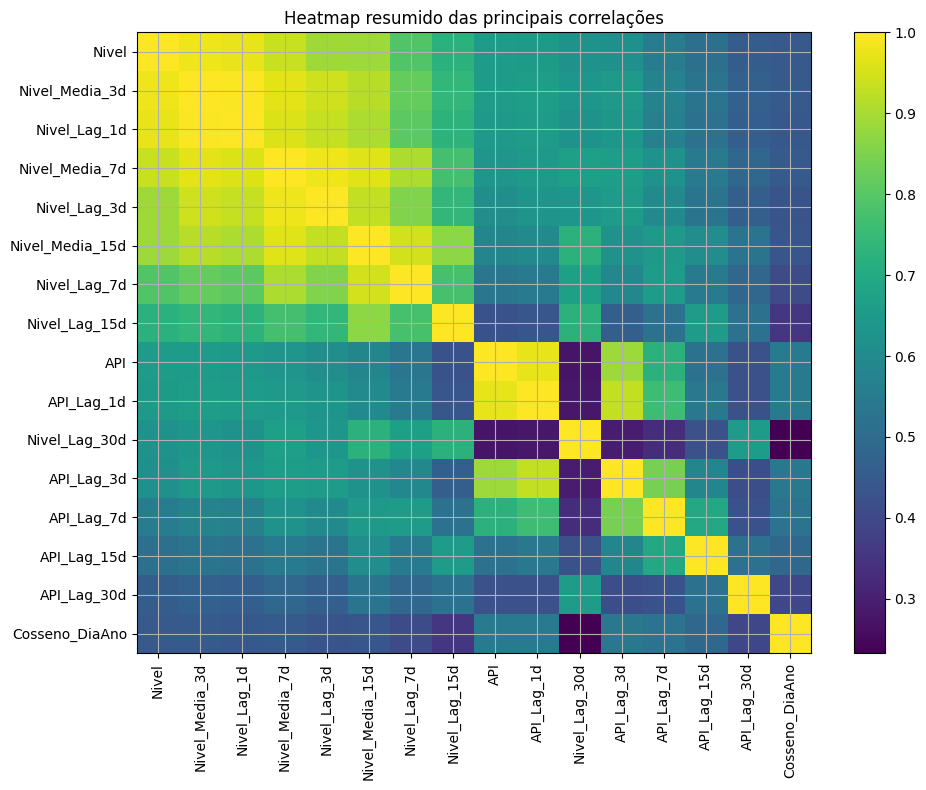

In [14]:
top_features = (
    cor_target.drop(index="Nivel")
    .assign(abs_corr=lambda x: x["Nivel"].abs())
    .sort_values("abs_corr", ascending=False)
    .head(15)
    .index
    .tolist()
)

colunas_heatmap = ["Nivel"] + top_features
matriz_corr = df_numerico[colunas_heatmap].corr()

fig, ax = plt.subplots(figsize=(10, 8))
imagem = ax.imshow(matriz_corr, aspect="auto")
ax.set_xticks(range(len(colunas_heatmap)))
ax.set_yticks(range(len(colunas_heatmap)))
ax.set_xticklabels(colunas_heatmap, rotation=90)
ax.set_yticklabels(colunas_heatmap)
ax.set_title("Heatmap resumido das principais correlações")
plt.colorbar(imagem, ax=ax)
plt.tight_layout()
plt.show()

## 15. Comparação resumida entre a base processada e a base de features

Esta célula resume o impacto da Fase 2 sobre o dataset oficial.

In [15]:
resumo_comparativo = pd.DataFrame(
    {
        "base": ["df_base", "df_features"],
        "linhas": [len(df_base), len(df_features)],
        "colunas": [df_base.shape[1], df_features.shape[1]],
        "data_inicial": [df_base.index.min(), df_features.index.min()],
        "data_final": [df_base.index.max(), df_features.index.max()],
    }
)

display(resumo_comparativo)

,base,linhas,colunas,data_inicial,data_final
0,df_base,7749,2,2005-01-01,2026-03-20
1,df_features,7659,36,2005-04-01,2026-03-20


## 16. Conclusões da Fase 2

A partir das validações deste notebook, espera-se confirmar que:

- a base de features foi gerada com sucesso;
- a perda de linhas é compatível com as defasagens adotadas;
- as famílias de features preservam coerência hidrológica e temporal;
- a saída da Fase 2 está pronta para alimentar a próxima etapa do estudo.

### Próximo passo esperado

Na sequência, a Fase 3 deverá:

- estruturar janelas/sequências temporais;
- separar treino, validação e teste em ordem cronológica;
- aplicar normalização sem vazamento temporal;
- preparar os tensores de entrada para LSTM e possíveis modelos futuros.